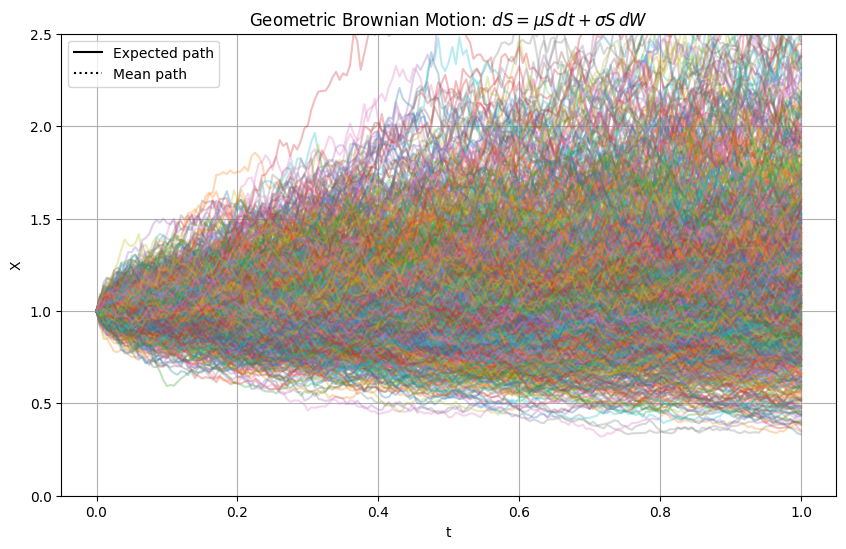

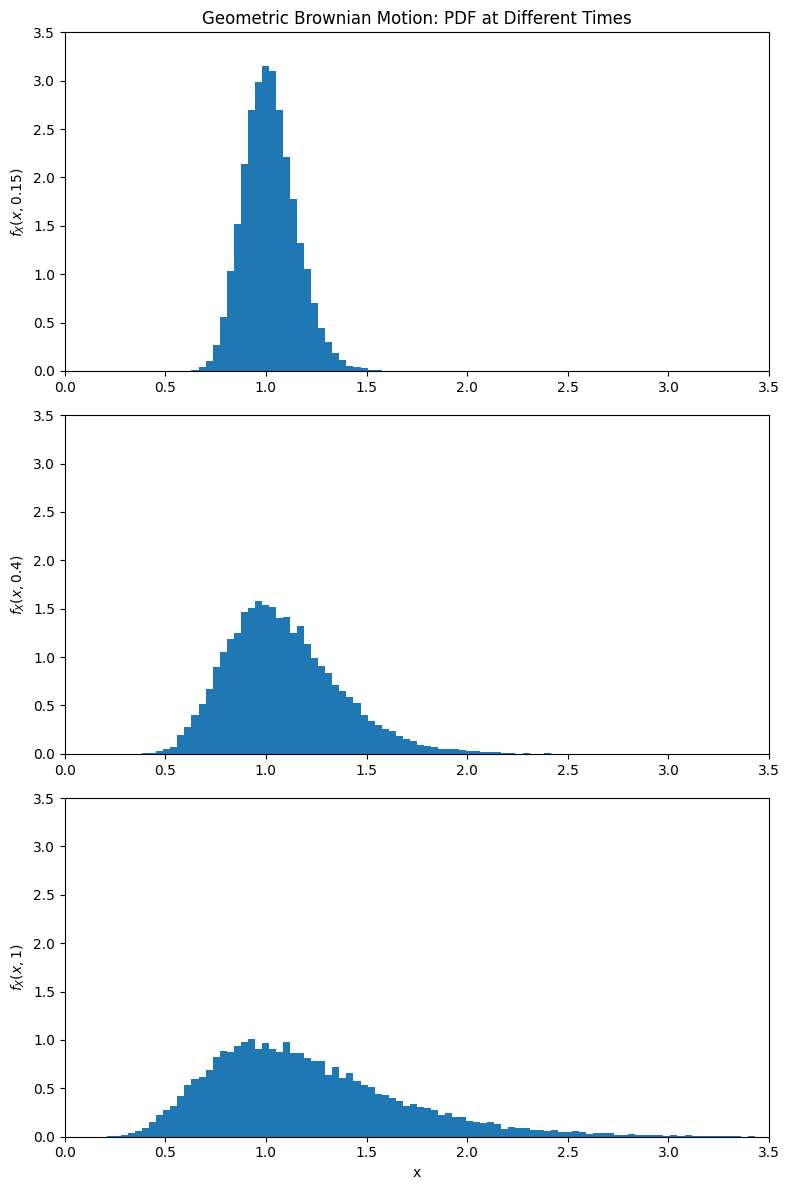

In [181]:
import numpy as np
import matplotlib.pyplot as plt

# Define parameters and time grid
npaths = 20000  # number of paths
T = 1  # time horizon
nsteps = 200  # number of time steps
dt = T / nsteps  # time step
t = np.linspace(0, T, nsteps + 1)  # observation times
mu, sigma = 0.2, 0.4  # model parameters
S0 = 1  # initial stock price

# Monte Carlo simulation
# Compute the increments of the arithmetic Brownian motion X = log(S/S0)
dX = (mu - 0.5 * sigma**2) * dt + sigma * np.random.randn(npaths, nsteps) * np.sqrt(dt)

# Accumulate the increments
X = np.cumsum(dX, axis=1)
X = np.hstack((np.zeros((npaths, 1)), X))  # Add initial condition X0 = 0

# Transform to geometric Brownian motion
S = S0 * np.exp(X)

# Expected, mean, and sample paths
plt.figure(figsize=(10, 6))
EX = np.exp(mu * t)  # expected path
plt.plot(t, EX, 'k', label='Expected path')
plt.plot(t, np.mean(S, axis=0), ':k', label='Mean path')
plt.plot(t, S[:1000, :].T, alpha=0.3)  # Sample paths
plt.xlabel('t')
plt.ylabel('X')
plt.ylim([0, 2.5])
plt.legend()
plt.title('Geometric Brownian Motion: $dS = \mu S \, dt + \sigma S \, dW$')
plt.grid(True)
plt.savefig('gbppaths.png')
plt.show()

# Probability density function at different times
plt.figure(figsize=(8, 12))

# Histogram at t = 0.15
plt.subplot(3, 1, 1)
plt.hist(S[:, 20], bins=np.arange(0, 3.5, 0.035), density=True)
plt.ylabel('$f_X(x, 0.15)$')
plt.xlim([0, 3.5])
plt.ylim([0, 3.5])
plt.title('Geometric Brownian Motion: PDF at Different Times')

# Histogram at t = 0.4
plt.subplot(3, 1, 2)
plt.hist(S[:, 80], bins=np.arange(0, 3.5, 0.035), density=True)
plt.ylabel('$f_X(x, 0.4)$')
plt.xlim([0, 3.5])
plt.ylim([0, 3.5])

# Histogram at t = 1.0
plt.subplot(3, 1, 3)
plt.hist(S[:, -1], bins=np.arange(0, 3.5, 0.035), density=True)
plt.xlabel('x')
plt.ylabel('$f_X(x, 1)$')
plt.xlim([0, 3.5])
plt.ylim([0, 3.5])

plt.tight_layout()
plt.savefig('gbpdensities.png')
plt.show()